# Milestone 2 - Skiing Conditions and Comfort
Claudia, Paige, Paula

## 1. Design the Threat Index

### Design Factors

#### What is the focus for the threat index?
We are focusing on an application-specific impact for our threat index where weather impacts skiing conditions.  

#### What is our target audience?
Our target audience would be the general public who enjoy the outdoor sport of skiing/snowboarding.


#### What is the appropriate scale or range for the index?
Our scale would be from 0-10. Zero meaning no skiing and ten meaning perfect conditions.

#### NWP model variables
The variables we'll be working with are, temperature(2m), total snow precipitation, wind speed, and total cloud cover.

### Developing a formula: Threat Index Example: Skiing Index
- Range: 0 to 100
- 0 = no skiing (mountain is closed)
- 100 = best possible

Best possible conditions:
- temperature between 20 - 32 F
- less than 50% cloud cover
- wind speed less than 50 mph
- total snow precipitation from 0-6 in 

Weighting:
- temperature: 40%
- clouds: 10%
- wind: 20%
- total snow precipitation: 30%

Temperature contribution:
- 0 when T > 50 F
- 1 when 20 <= T <= 32
- 0 when T < 0
- function slope from 0 - 20 and 32 - 50


#### Function for temp distribution:

y = 0 {x < 0}

y = (1 - ((20 - x)/20)^2) {0 <= x < 20}

y = 1 {20 <= x <= 32}

y = (1 - ((x - 32)/18)^2) {32 < x <= 50}

y = 0 {x > 50}


#### Function for cloud cover:

y = (0.01x + 0.5){0 ≤ x ≤ 50}

y = (-0.01x + 1.5){50 ≤ x ≤ 100}


#### Function for wind speed: 

y = (-1/50)x -1 {0 < x < 50}


#### Function for snow depth:

y = 1 {x > 6}

y = ((1/6)(x)) {0 <= x <= 6}


### Imports

In [8]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs, cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import xarray as xr
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Data Code

In [2]:
ds = xr.open_dataset('gfs.nc')

sh: 1: getfattr: not found


In [3]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:            (valid_time: 40, latitude: 81, longitude: 81)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 320B 2026-02-22 ... 2026-0...
  * latitude           (latitude) float64 648B 55.0 54.75 54.5 ... 35.25 35.0
  * longitude          (longitude) float64 648B 280.0 280.2 ... 299.8 300.0
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 320B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    atmosphere         float64 8B ...
Data variables:
    sde                (valid_time, latitude, longitude) float32 1MB ...
    t2m                (valid_time, latitude, longitude) float32 1MB ...
    tp                 (valid_time, latitude, longitude) float32 1MB ...
    tcc                (valid_time, latitude, longitude) float32 1MB ...
    u10                (valid_time, latitude, longitude) float32 1MB ...
    v10                (valid_time, latitude, longitude) float32 1MB ...
    csnow              (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T17:15 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# Selecting a time in the data set to work with
chosen_hour = 6
s_ds = ds.isel(valid_time = chosen_hour)   

In [13]:
# Selecting the northeast of the united states: 
ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))  

#Extracting variables:
t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit

tcc = ds_ne['tcc'].values #%

u = ds_ne['u10'].values * 2.23694 
v = ds_ne['v10'].values * 2.23694 
wind = np.sqrt(u**2 + v**2) #mph

sde = ds_ne['sde'].values * 100 #Cm

csnow = ds_ne['csnow'].values #catagorial snow

tp = ds_ne['tp'].values * 2.54 #in inches and changed to snow from liquid using ratio 10:1

lat = ds_ne.latitude.values
lon = ds_ne.longitude.values

In [14]:
# Extracting values for 6 hr interval for the total snow precip. 
tp_chosenhr= ds.tp.isel(valid_time= chosen_hour).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_prevhr = ds.tp.isel(valid_time= chosen_hour - 1).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_interval = tp_chosenhr - tp_prevhr
tp_interval = tp_interval * 0.03937 * 10 #in inches and changed to snow from liquid using ratio 10:1

#### 2 Meter Temperature

Text(0.5, 1.0, '2 Meter Temperature (contribution)\n Valid Time: 12:00 UTC Feb 23 2026')

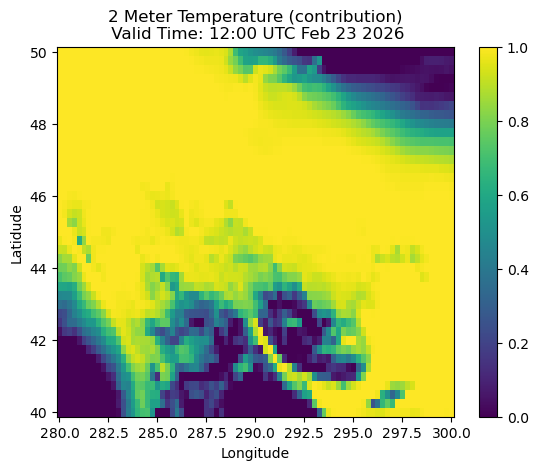

In [20]:
# Contribution: 
t2m_contribution = np.zeros_like(t2m_f)
 
valid_time = datetime.strptime(str(s_ds.valid_time.values)[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the plot

# 0 <= T < 20 : increase from 0 to 1
mask = (t2m_f >= 0) & (t2m_f < 20)
t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)

# 20 <= T <= 32 : contribution = 1
mask = (t2m_f >= 20) & (t2m_f <= 32)
t2m_contribution[mask] = 1.0

# 32 < T < 50 : decrease from 1 to 0.5
mask = (t2m_f > 32) & (t2m_f < 50)
t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)

# T >- 50 : contribution = 0
mask = t2m_f >= 50
t2m_contribution[mask] = 0


# Plotting: 
plt.pcolormesh(lon, lat, np.flipud(t2m_contribution))
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.title(f"2 Meter Temperature (contribution)\n Valid Time: {valid_time}")

#### Total Cloud Cover

Text(0.5, 1.0, 'Total Cloud Cover (contribution)\n Valid Time: 12:00 UTC Feb 23 2026')

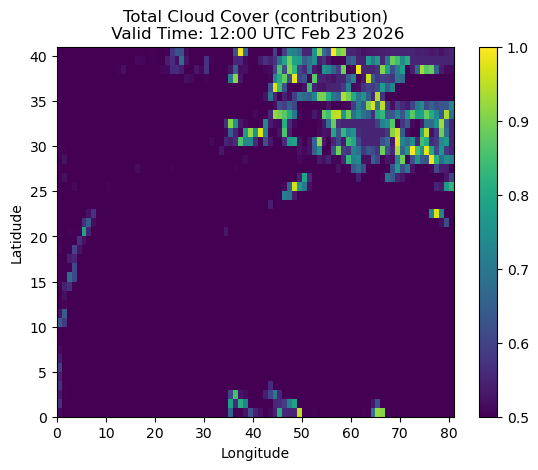

In [21]:
# Contribution:
tcc_contribution = np.zeros_like(tcc)

# 0 <= tcc <= 50 : linear increase from 0% to 50%
mask = (tcc >= 0) & (tcc <= 50)
tcc_contribution[mask] = (0.01)*(tcc[mask]) + 0.5

# 50 < tcc <= 100 : linear decrease from 50% tp 100%
mask = (tcc > 50)
tcc_contribution[mask] = (-0.01)*(tcc[mask]) + 1.5

# Plotting:
plt.pcolormesh(np.flipud(tcc_contribution))
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.title(f"Total Cloud Cover (contribution)\n Valid Time: {valid_time}")

#### Wind

Text(0.5, 1.0, 'Wind (contribution)\n Valid Time: 12:00 UTC Feb 23 2026')

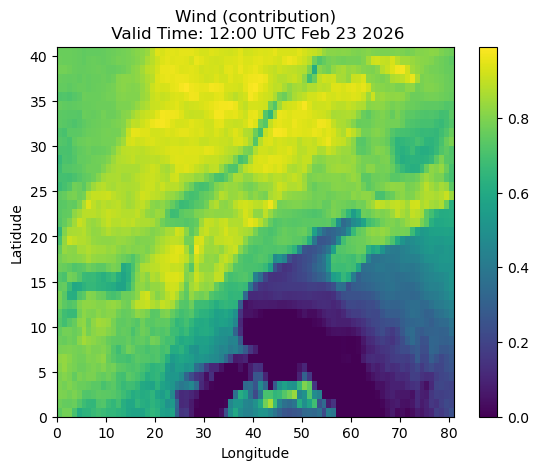

In [22]:
# Contribution:
wind_contribution = np.zeros_like(wind)

# 0 <= T <= 50 : increase
mask = (wind >= 0) & (wind <= 50)
wind_contribution[mask] = ((-1/50)*(wind[mask])) + 1

#Plotting: 
plt.pcolormesh(np.flipud(wind_contribution))
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.title(f"Wind (contribution)\n Valid Time: {valid_time}")

#### Total Snow Precipitation

Text(0.5, 1.0, 'Total Snow Precipitation (contribution)\n Valid Time: 18:00 UTC Mar 03 2026')

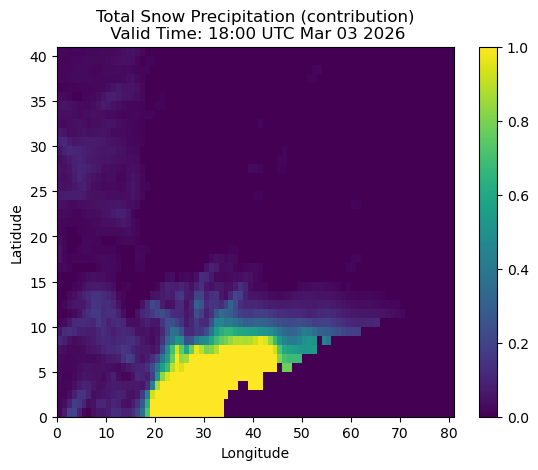

In [45]:
#Choosing Where it's Snowing and not Raining
tp_snow_only = np.where(csnow == 1, tp_interval, 0)
tp_contribution = np.zeros_like(tp_snow_only)

#Masking for tp
mask = (tp_snow_only >= 0) & (tp_snow_only <= 6)
tp_contribution[mask] = ((1/6)*(tp_snow_only[mask]))
mask = (tp_snow_only > 6)
tp_contribution[mask] = 1

# plt.pcolormesh(np.flipud(tp_snow_only))
plt.pcolormesh(np.flipud(tp_contribution))
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.title(f"Total Snow Precipitation (contribution)\n Valid Time: {valid_time}")

#### Final Equation

Text(0.5, 1.0, 'Final Equation\n Valid Time: 18:00 UTC Mar 03 2026')

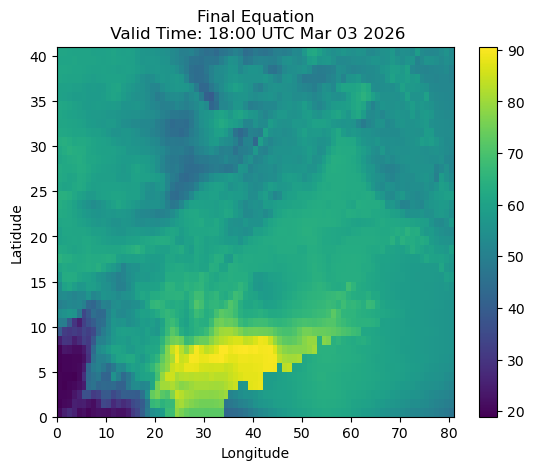

In [46]:
PUI = (t2m_contribution*0.4 + tcc_contribution*0.1 + wind_contribution*0.2 + tp_contribution*0.3)*100

# Plotting the Final Equation: 
plt.pcolormesh(np.flipud(PUI))
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.title(f"Final Equation\n Valid Time: {valid_time}")

### Brainstorming
#### Reasoning for choosing the variables: 
These are variables that skiers often reference when choosing a day to enjoy the sport. 

#### Why this index would be useful to our audience:
It provides a clear description and system for accurate skiing conditions. 

#### How the formula works and why it makes sense:
????

#### How each variable is weighted or combined:
????


## 2. Implementing the Algorithm

## Choosing an efficient time step

In [26]:
chosen_ts = [1,3,5,7,9,11]

## Defining a function

In [27]:
#making def to accept xrray with our variables and then calculating the threat index based on our previous PUI formula
def threat_index(ds, chosen_ts):
    s_ds = ds.isel(valid_time = chosen_ts) 
    # print(s_ds.valid_time)
    
    ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))   #selecting the northeast of the united states

    t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit
    tcc = ds_ne['tcc'].values #%
    u = ds_ne['u10'].values * 2.23694 
    v = ds_ne['v10'].values * 2.23694 
    wind = np.sqrt(u**2 + v**2) #mph
    csnow= ds_ne['csnow'].values
    tp_chosenhr= ds.tp.isel(valid_time= chosen_ts).values
    tp_prevhr = ds.tp.isel(valid_time= chosen_ts - 1).values
    tp_interval = tp_chosenhr - tp_prevhr
    
    sde = ds_ne['sde'].values * 100 #Cm
    
    #2 Meter Temperature
    t2m_contribution = np.zeros_like(t2m_f)
    # 0 <= T < 20 : increase from 0 to 1
    mask = (t2m_f >= 0) & (t2m_f < 20)
    t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)
    # 20 <= T <= 32 : contribution = 1
    mask = (t2m_f >= 20) & (t2m_f <= 32)
    t2m_contribution[mask] = 1.0
    # 32 < T < 50 : decrease from 1 to 0.5
    mask = (t2m_f > 32) & (t2m_f < 50)
    t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)
    # T >- 50 : contribution = 0
    mask = t2m_f >= 50
    t2m_contribution[mask] = 0
    #plt.pcolormesh(np.flipud(t2m_contribution))

    #Total Cloud Cover
    tcc_contribution = np.zeros_like(tcc)
    # 0 <= tcc <= 50 : linear increase from 0% to 50%
    mask = (tcc >= 0) & (tcc <= 50)
    tcc_contribution[mask] = (0.01)*(tcc[mask]) + 0.5
    # 50 < tcc <= 100 : linear decrease from 50% tp 100%
    mask = (tcc > 50)
    tcc_contribution[mask] = (-0.01)*(tcc[mask]) + 1.5
    #plt.pcolormesh(np.flipud(tcc_contribution))

    #Wind
    wind_contribution = np.zeros_like(wind)
    # 0 <= T <= 50 : increase
    mask = (wind >= 0) & (wind <= 50)
    wind_contribution[mask] = ((-1/50)*(wind[mask])) + 1
    #plt.pcolormesh(np.flipud(wind_contribution))

    #Snow Depth
    sde_contribution = np.zeros_like(sde)
    # sde < 25 : contribution = 0
    mask = (sde < 25)
    sde_contribution[mask] = 0
    # 25 <= sde <= 500 : linear increase to 500 (max possible snow depth in northeast)
    mask = (sde >= 25) & (sde <= 500)
    sde_contribution[mask] = ((1/500)*((sde[mask]) - 25))
    #plt.pcolormesh(np.flipud(sde_contribution))
    #total snow precip 
    tp_chosenhr= ds.tp.isel(valid_time= chosen_ts).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
    tp_prevhr = ds.tp.isel(valid_time= chosen_ts - 1).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
    tp_interval = tp_chosenhr - tp_prevhr
    tp_interval = tp_interval * 0.03937 * 10 #in inches and changed to snow from liquid using ratio 10:1
    tp_snow_only = np.where(csnow == 1, tp_interval, 0)
    tp_contribution = np.zeros_like(tp_snow_only)
    mask = (tp_snow_only >= 0) & (tp_snow_only <= 6)
    tp_contribution[mask] = ((1/6)*(tp_snow_only[mask]))
    mask = (tp_snow_only > 6)
    tp_contribution[mask] = 1

    #final equation
    PUI = (t2m_contribution*0.4 + tcc_contribution*0.1 + wind_contribution*0.2 + tp_contribution*0.3)*100
    #plt.pcolormesh(np.flipud(PUI))
    
    return PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution #returning the array containing values

    #have return index have threat index and input varibles

## 3. Visualizing the Output

## Creating multi-panel plot (using sublots)  

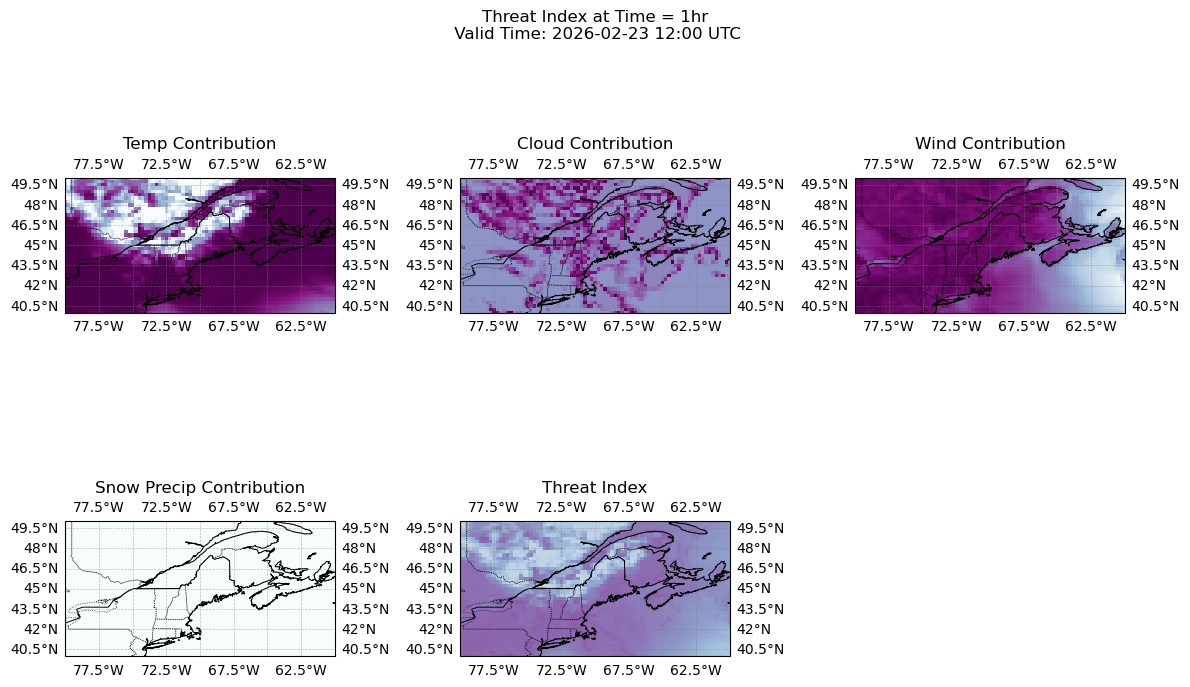

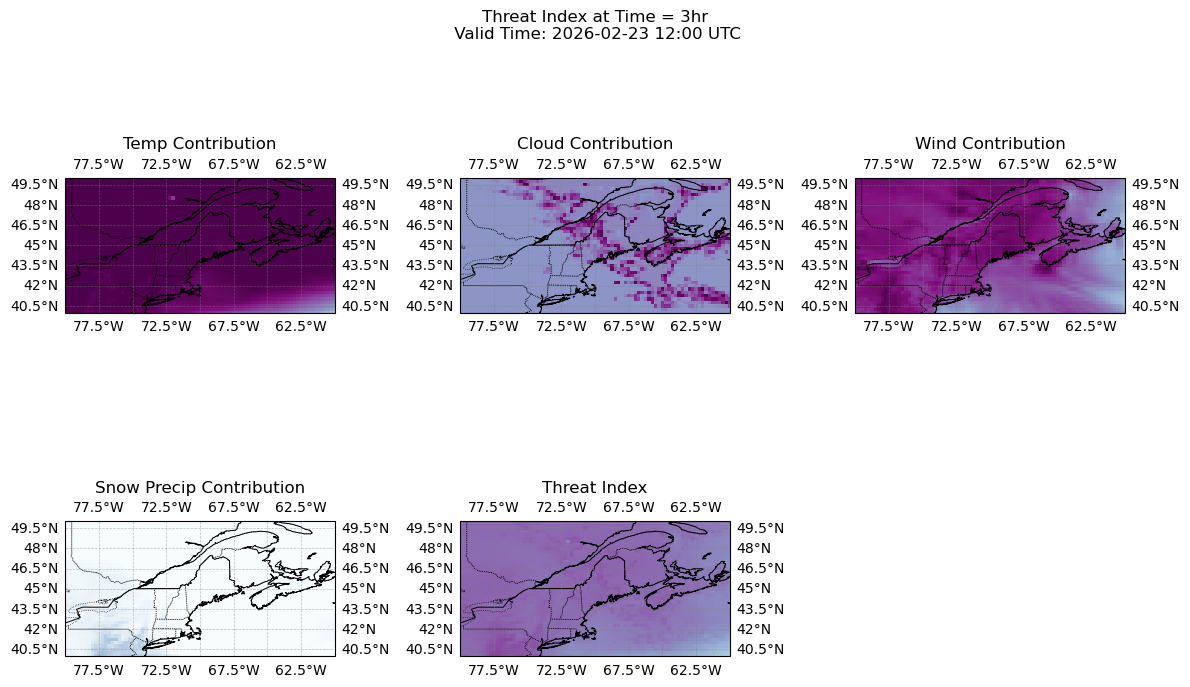

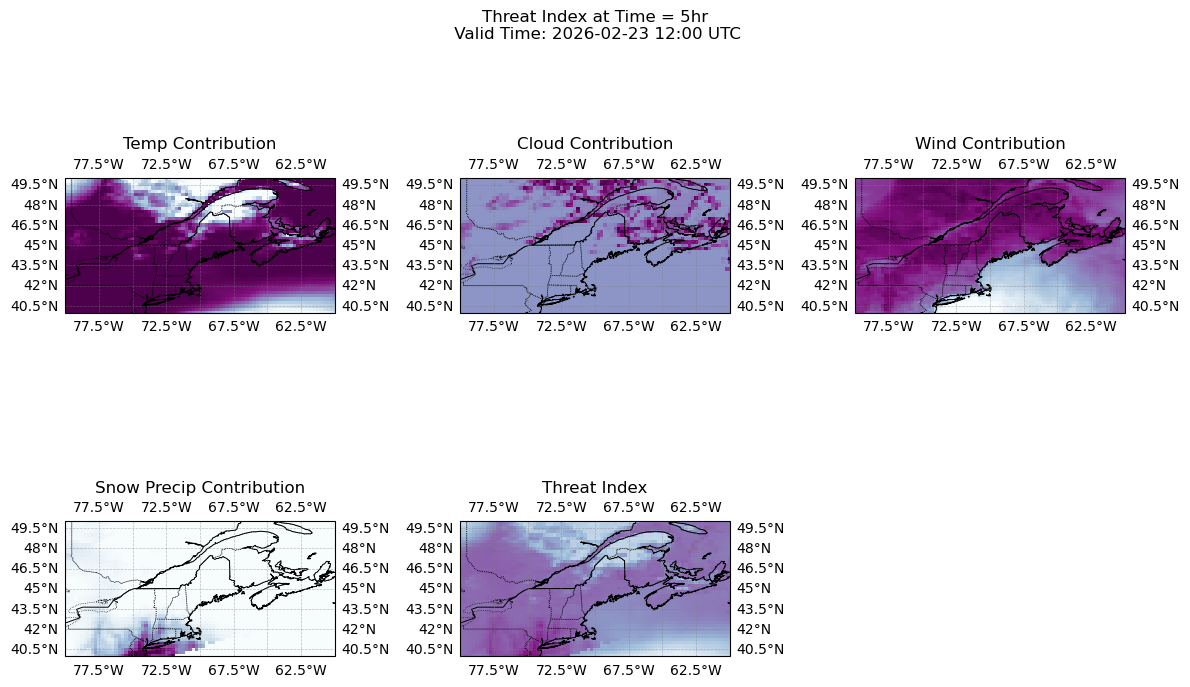

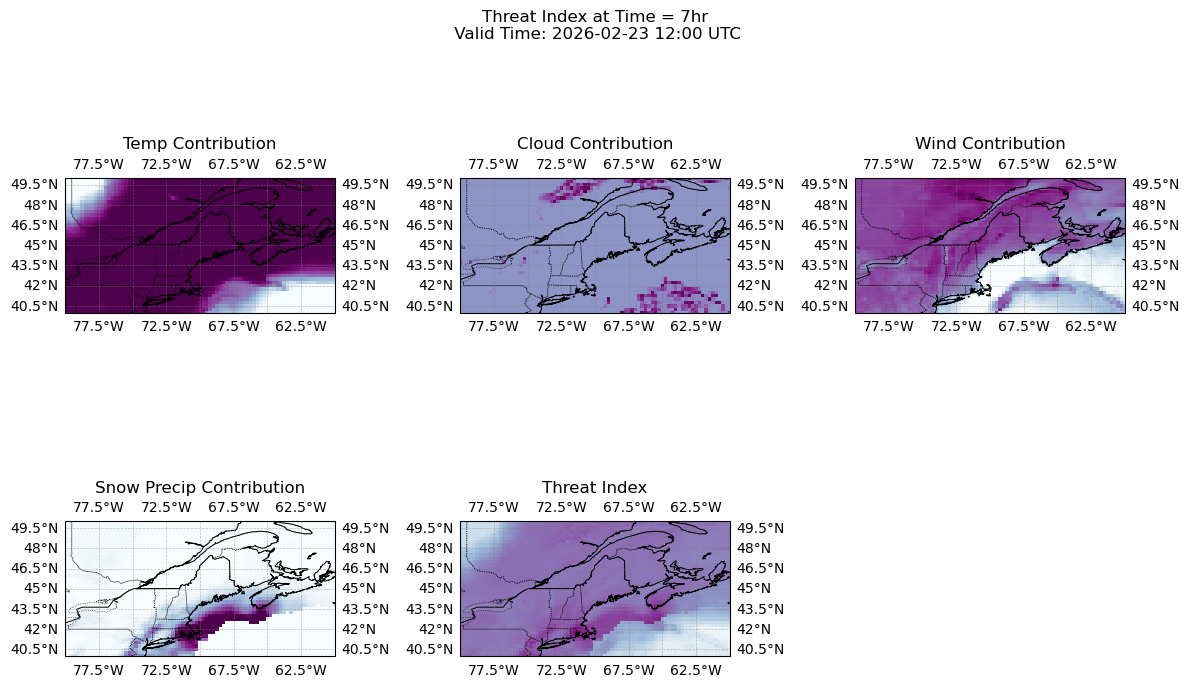

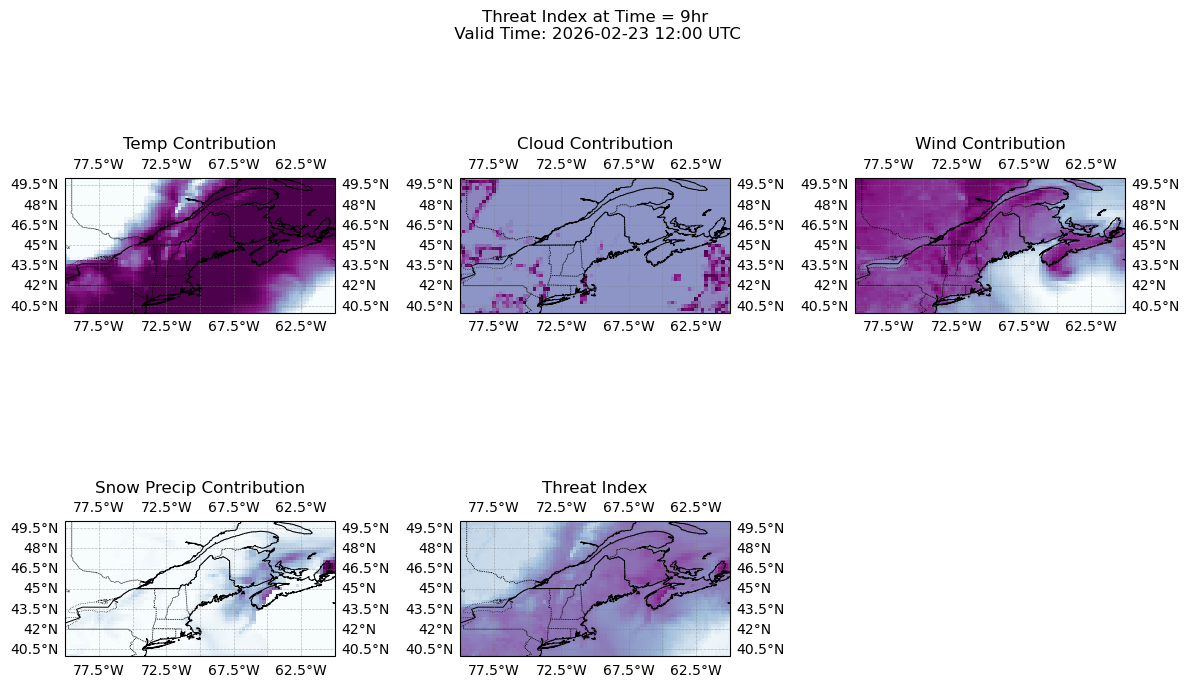

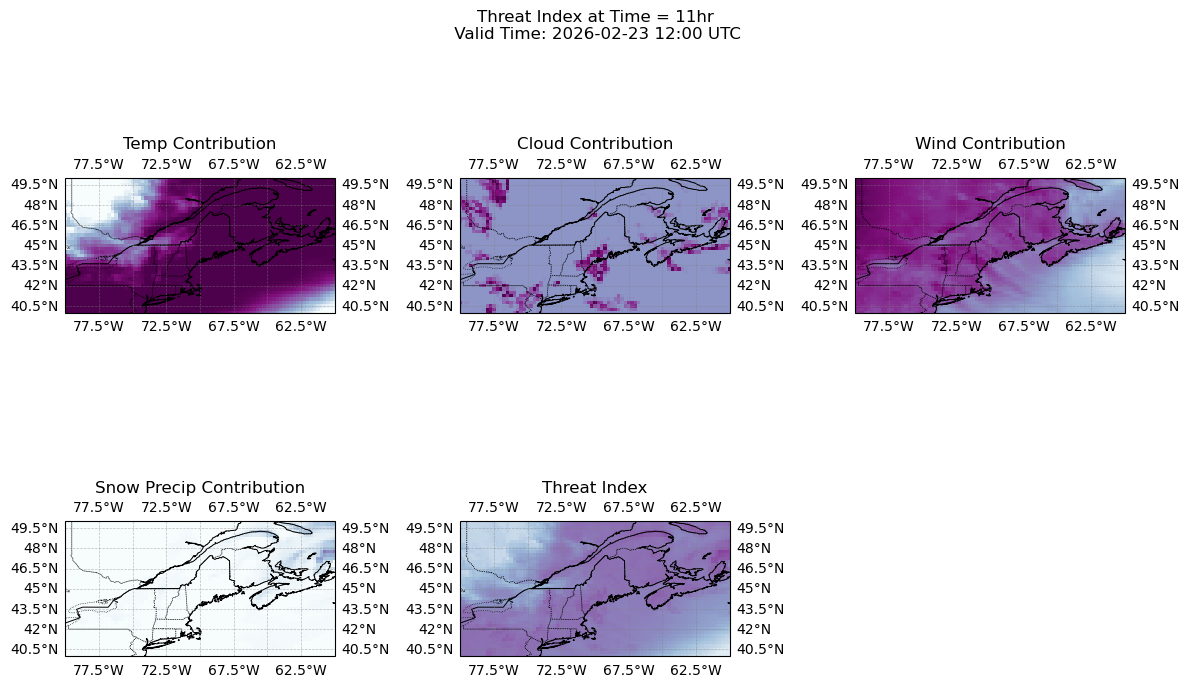

In [28]:
def basemap():
    fig = plt.figure(figsize = (12,8))
    axs = fig.subplots(nrows = 2, ncols = 3, subplot_kw = {'projection': ccrs.PlateCarree()})
    for ax in axs.flatten():
        ax.set_extent([-80,-60,40,50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth = 0.7)
        ax.add_feature(cfeature.STATES, linestyle=':', linewidth = 0.5)
        ax.add_feature(cfeature.BORDERS, linewidth = 0.7)
    
        gridlines = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 0.5, color = 'gray', alpha = 0.5, linestyle = '--')

        #removing the extra '6th' axes that we do not need
        axs[1,2].set_visible(False)  

    return fig, axs

for t in chosen_ts: #Generating plot for 6 different time steps from our model run
    lat = ds_ne.latitude.values
    lon = ds_ne.longitude.values
    PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution = threat_index(ds, t)
    valid_time = pd.to_datetime(s_ds.valid_time.values).strftime('%Y-%m-%d %H:%M UTC')
    
    fig, axs = basemap()
    #Plots 1-4: plots of each of the input parameters 
    plot1 = axs[0,0].pcolormesh(lon, lat, t2m_contribution , transform = ccrs.PlateCarree(), cmap='BuPu',  vmin = 0, vmax = 1)
    axs[0,0].set_title("Temp Contribution") #Plot Temp Contribution
    
    plot2 = axs[0,1].pcolormesh(lon, lat, tcc_contribution , transform = ccrs.PlateCarree(), cmap='BuPu',  vmin = 0, vmax = 1)
    axs[0,1].set_title("Cloud Contribution") #Plot Cloud Contribution
    
    plot3 = axs[0,2].pcolormesh(lon, lat, wind_contribution , transform = ccrs.PlateCarree(), cmap='BuPu',  vmin = 0, vmax = 1)
    axs[0,2].set_title("Wind Contribution") #Plot Wind Contribution
    
    plot4 = axs[1,0].pcolormesh(lon, lat, tp_contribution , transform = ccrs.PlateCarree(), cmap='BuPu',  vmin =0, vmax = 1)
    axs[1,0].set_title("Snow Precip Contribution") #Plot Snow Precip Contribution
    
    plot5 = axs[1,1].pcolormesh(lon, lat, PUI , transform = ccrs.PlateCarree(), cmap='BuPu',  vmin = 0, vmax = 100)
    axs[1,1].set_title("Threat Index") #Plot of the threat index
    
    
    fig.suptitle(f"Threat Index at Time = {t}hr\n Valid Time: {valid_time}") #NEED TO IMPROVE
    fig.tight_layout() 
    plt.show()

In [29]:
PUI, t2m_contribution, tcc_contribution, wind_contribution, sde_contribution = threat_index(ds, 6)

## 4. Test the Algorithm on Additional Events

## Opening Two Datasets

In [30]:
#High-end Case: January 25, 2026 
ds_high = xr.open_dataset("gfs.nc_high")

#Low-end Case: January 29, 2025
ds_low = xr.open_dataset("gfs.nc_low")

sh: 1: getfattr: not found
sh: 1: getfattr: not found


## Extracting same variables for these datasets and running it through threat index:

### High-end:

In [31]:
PUI_high, t2m_c, tcc_c, wind_c, tp_c = threat_index(ds_high, chosen_hour)

### Low-end:

In [32]:
PUI_low, t2m_c, tcc_c, wind_c, tp_c = threat_index(ds_low, chosen_hour)

## Plotting and Comparing

### Plotting High to Visualize

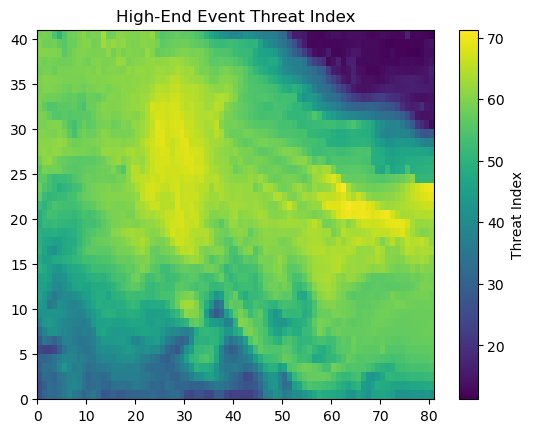

In [33]:
plt.pcolormesh(PUI_high)
plt.colorbar(label="Threat Index")
plt.title("High-End Event Threat Index")
plt.show()

### Plotting Low to Visualize

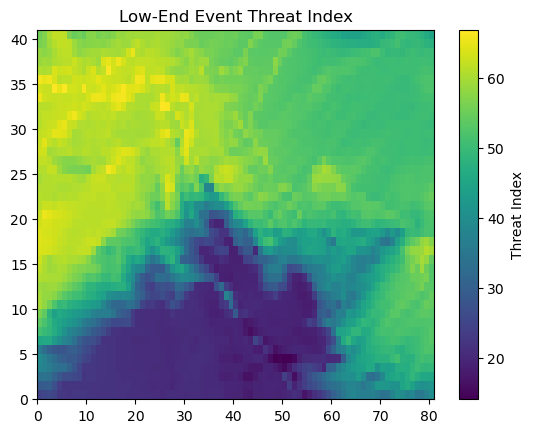

In [34]:
plt.pcolormesh(PUI_low)
plt.colorbar(label="Threat Index")
plt.title("Low-End Event Threat Index")
plt.show()

### Evaluating algoritm's performance: 

#### Did it produce reasonable values: 
Yes it did produce reasonables values because the high-end plot displayed variation across the man and it showed the higher values in stormy areas and vice-versa for the low-end case. 

#### Were there false alarms or missed threats?
????

#### Did we need to revise the formula? If so, how?
???? 

## 5. Automate Plot Generation

In [44]:
#Modifying code to produce a plot of our threat index for every time step in the model run
for t in range(len(ds.valid_time)):
    
    PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution = threat_index(ds, t)
    
    s_ds = ds.isel(valid_time=t)
    ds_ne = s_ds.sel(latitude=slice(50,40), longitude=slice(280,300))
    
    lat = ds_ne.latitude.values
    lon = ds_ne.longitude.values
    
    valid_time = datetime.strptime(str(s_ds.valid_time.values)[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the plot
    
    fig = plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    ax.set_extent([-80, -60, 40, 50])
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linestyle=':')
    
    plot = ax.pcolormesh(lon, lat, PUI, transform=ccrs.PlateCarree(),cmap='BuPu', vmin=0, vmax=100)
    
    axins = inset_axes(ax, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax.transAxes, borderpad = 0)
    plt.colorbar(plot, cax = axins, orientation = 'horizontal', label = 'Threat Index')

    
    ax.set_title(f"Threat Index\nValid Time: {valid_time}")
    

    plt.savefig(f"threat_{t:03d}.png", dpi=150, bbox_inches='tight') #Saving each plot as a .png file with name
    
    plt.close()


# 6. Converting to Python Script

# 7. Bonus